# Statistical Analysis of Cleaned Housing Dataset


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

BLUE, ORANGE, GREEN, RED, PURPLE = '#2563EB','#F97316','#16A34A','#DC2626','#7C3AED'

Housing_cleaned = pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Housing_Project\Housing_Cleaned.csv")
print(f'Dataset shape: {Housing_cleaned.shape}')
Housing_cleaned.head()

Dataset shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,furnishingstatus_enc
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,2


In [14]:
# Descriptive statistic
num_cols = ['price','area','bedrooms','bathrooms','stories','parking']
desc_stats = []
for col in num_cols:
    mean_v = Housing_cleaned[col].mean()
    median_v = Housing_cleaned[col].median()
    mode_v = Housing_cleaned[col].mode()[0]
    desc_stats.append({
        'Mean': mean_v,
        'Median': median_v,
        'Mode': mode_v
    })
pd.DataFrame(desc_stats, index=num_cols)

,Mean,Median,Mode
price,4.766729e+06,4340000.0,3500000
area,5.150541e+03,4600.0,6000
bedrooms,2.965138e+00,3.0,3
bathrooms,1.286239e+00,1.0,1
stories,1.805505e+00,2.0,2
parking,6.935780e-01,0.0,0


In [15]:
# Variance & Standard Deviation 
var_std_stats = []
for col in num_cols:
    var_v = Housing_cleaned[col].var()
    std_v = Housing_cleaned[col].std()
    var_std_stats.append({
        'Column': col,
        'Variance': var_v,
        'Std Dev': std_v
    })
pd.DataFrame(var_std_stats)

,Column,Variance,Std Dev
0,price,3.498544e+12,1.870440e+06
1,area,4.709512e+06,2.170141e+03
2,bedrooms,5.447383e-01,7.380639e-01
3,bathrooms,2.524757e-01,5.024696e-01
4,stories,7.525432e-01,8.674925e-01
5,parking,7.423300e-01,8.615858e-01


In [16]:
# Skewness & Kurtosis 
Skew_Kurt_stats = []
for col in num_cols:
    skew_v = Housing_cleaned[col].skew()
    kurt_v = Housing_cleaned[col].kurt()
    Skew_Kurt_stats.append({
        'Column': col,
        'Skewness': skew_v,
        'Kurtosis': kurt_v
    })
pd.DataFrame(Skew_Kurt_stats)


,Column,Skewness,Kurtosis
0,price,1.212239,1.960130
1,area,1.321188,2.751480
2,bedrooms,0.495684,0.728323
3,bathrooms,1.589264,2.164856
4,stories,1.082088,0.679404
5,parking,0.842062,-0.573063


### Interpretation

1. **Positive skewness (> 0)** indicates a right-skewed distribution, where the tail extends toward larger values.

2. **Price (skewness = 1.21)** and **Area (skewness = 1.32)** are both positively skewed, indicating that most properties have relatively lower prices and smaller areas, while a small number of high-priced, large properties create a long right tail and increase the mean above the median.

3. Since both skewness values exceed 1, the distributions can be considered **highly right-skewed**, suggesting the presence of potential outliers in the upper ranges of Price and Area.


In [17]:
Housing_cleaned[num_cols].describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Descriptive Statistics  Key Observations

* **Price:** The mean price (£4.77M) exceeds the median price (£4.34M), indicating a positively skewed distribution. A relatively small number of high-value properties increase the average price.

* **Area:** Area exhibits the greatest relative variability among the numeric features, with a coefficient of variation (CV) of approximately 42%. This suggests substantial differences in property sizes across the dataset.

* **Bedrooms and Bathrooms:** These variables show comparatively low variability, indicating that most properties are concentrated around 2–3 bedrooms and 1–2 bathrooms.

* **Distribution Shape:** The differences between the mean and median for both Price and Area suggest that these variables are not symmetrically distributed. This observation is consistent with the positive skewness identified in the earlier analysis.


# Probability Distributions

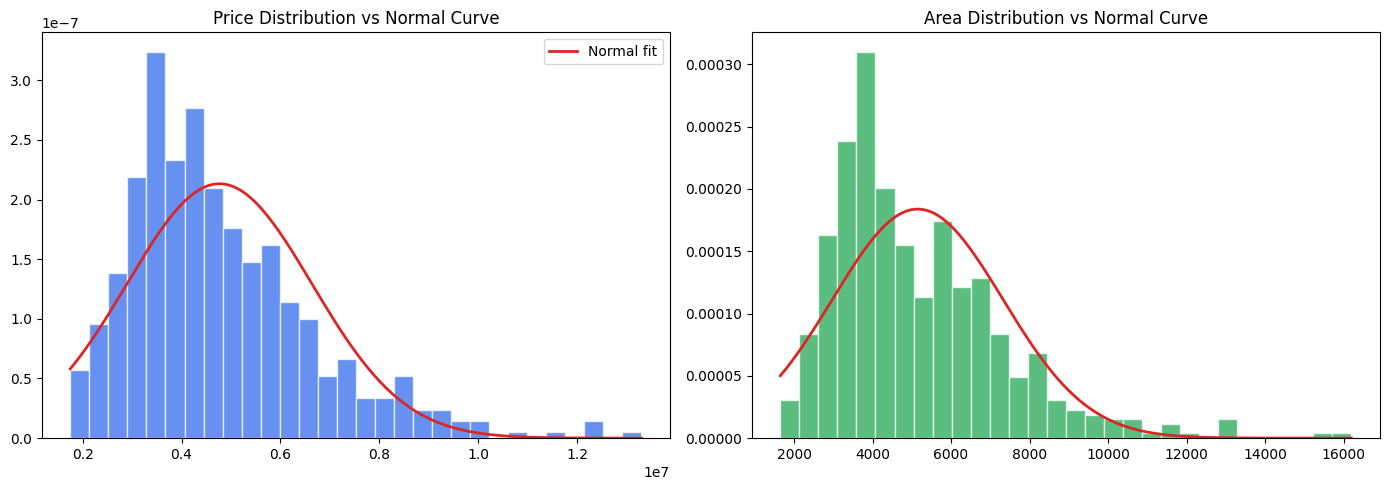

In [18]:
# Histogram + Normal curve overlay 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price
ax = axes[0]
ax.hist(Housing_cleaned['price'], bins=30, density=True, color=BLUE, alpha=0.7, edgecolor='white')
mu, sigma = Housing_cleaned['price'].mean(), Housing_cleaned['price'].std()
x = np.linspace(Housing_cleaned['price'].min(), Housing_cleaned['price'].max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color=RED, linewidth=2, label='Normal fit')
ax.set_title('Price Distribution vs Normal Curve'); ax.legend()

# Area
ax = axes[1]
ax.hist(Housing_cleaned['area'], bins=30, density=True, color=GREEN, alpha=0.7, edgecolor='white')
mu2, sigma2 = Housing_cleaned['area'].mean(), Housing_cleaned['area'].std()
x2 = np.linspace(Housing_cleaned['area'].min(), Housing_cleaned['area'].max(), 200)
ax.plot(x2, stats.norm.pdf(x2, mu2, sigma2), color=RED, linewidth=2)
ax.set_title('Area Distribution vs Normal Curve')

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Housing_Project\Housing_Cleaned_Distributions.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

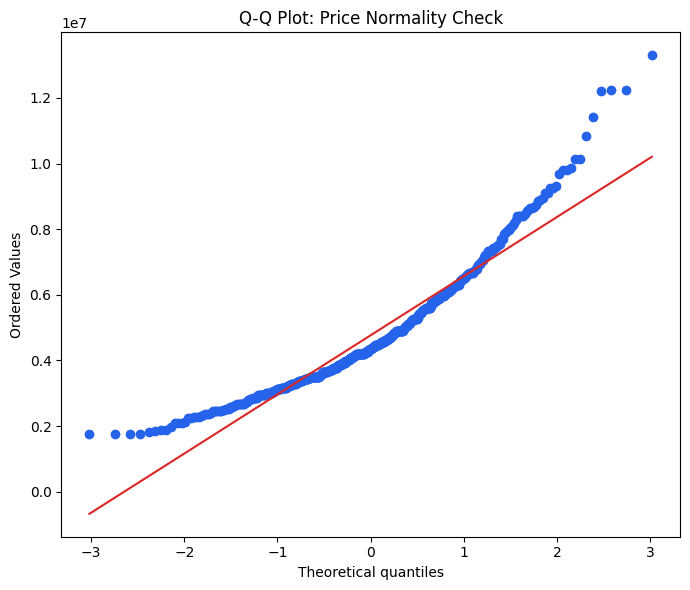

In [19]:
#  Q-Q Plot Formal normality check

fig, ax = plt.subplots(figsize=(7, 6))
stats.probplot(Housing_cleaned['price'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot: Price Normality Check')
ax.get_lines()[0].set_color(BLUE); ax.get_lines()[1].set_color(RED)
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Housing_Project\Housing_Cleaned_Normality_Check.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

In [20]:
# Shapiro-Wilk normality test
stat_price, p_price = stats.shapiro(Housing_cleaned['price'])

shapiro_results = pd.DataFrame({
    'Statistic': [stat_price],
    'P-Value': [p_price]
}, index=['Price'])

shapiro_results['Normal?'] = shapiro_results['P-Value'].apply(
    lambda x: 'No (p < 0.05)' if x < 0.05 else 'Yes'
)

shapiro_results

,Statistic,P-Value,Normal?
Price,0.921631,3.154903e-16,No (p < 0.05)


# Probability Distribution Key Observations

* Both **Price** and **Area** distributions deviate noticeably from the overlaid normal curve, particularly in the right tail, indicating positive skewness.

* The Q–Q plot shows systematic deviations from the reference line at both extremes, which is characteristic of non-normally distributed data with skewness and potential outliers.

* The Shapiro–Wilk test confirms this statistically: **Price is not normally distributed (p < 0.05)**, providing formal evidence against the assumption of normality.

* **Practical implication:** Since normality is violated, parametric tests that assume normally distributed data should be applied with caution. For smaller samples or heavily skewed variables, non-parametric alternatives (e.g., Mann–Whitney U test) may be more appropriate. However, with larger samples, the Central Limit Theorem may still support the use of mean-based inference methods.


# Hypothesis Testing

In [21]:
# Hypothesis Test 1: Does Air Conditioning affect Price?

# H0: No difference in mean price between AC and No AC homes
# H1: There IS a difference in mean price

ac_yes = Housing_cleaned[Housing_cleaned['airconditioning']==1]['price']
ac_no  = Housing_cleaned[Housing_cleaned['airconditioning']==0]['price']

t_stat, p_val = stats.ttest_ind(ac_yes, ac_no, equal_var=False)

conclusion = ("Reject H0 AC has a statistically significant effect on price"
              if p_val < 0.05 else "Fail to reject H0")

ttest_ac_results = pd.DataFrame({
    'Metric': ['Mean Price (AC)', 'Mean Price (No AC)', 'T-statistic', 'P-value', 'Conclusion'],
    'Value': [f'£{ac_yes.mean():,.0f}', f'£{ac_no.mean():,.0f}',
              f'{t_stat:.3f}', f'{p_val:.6f}', conclusion]
})

display(ttest_ac_results)

,Metric,Value
0,Mean Price (AC),"£6,013,221"
1,Mean Price (No AC),"£4,191,940"
2,T-statistic,10.659
3,P-value,0.000000
4,Conclusion,Reject H0 AC has a statistically significant e...


In [22]:
# Hypothesis Test 2: Does Preferred Area affect Price?

# H0: No difference in mean price between PrefArea and non-PrefArea homes
# H1: There IS a difference

pa_yes = Housing_cleaned[Housing_cleaned['prefarea']==1]['price']
pa_no  = Housing_cleaned[Housing_cleaned['prefarea']==0]['price']

t_stat2, p_val2 = stats.ttest_ind(pa_yes, pa_no, equal_var=False)

conclusion = ("Reject H0 — Location has a statistically significant effect on price"
              if p_val2 < 0.05 else "Fail to reject H0")

ttest_prefarea_results = pd.DataFrame({
    'Metric': ['Mean Price (Pref Area)', 'Mean Price (Not Pref Area)', 'T-statistic', 'P-value', 'Conclusion'],
    'Value': [f'£{pa_yes.mean():,.0f}', f'£{pa_no.mean():,.0f}',
              f'{t_stat2:.3f}', f'{p_val2:.6f}', conclusion]
})

display(ttest_prefarea_results)

,Metric,Value
0,Mean Price (Pref Area),"£5,879,046"
1,Mean Price (Not Pref Area),"£4,425,299"
2,T-statistic,7.492
3,P-value,0.000000
4,Conclusion,Reject H0 — Location has a statistically signi...


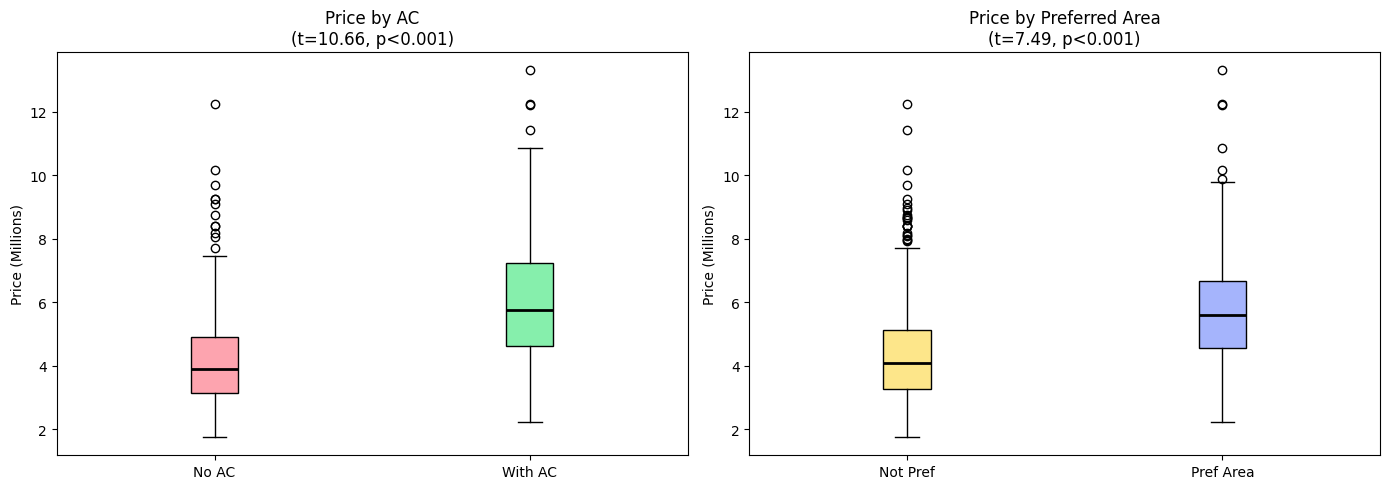

In [23]:
# Visualize both hypothesis tests with boxplots 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data1 = [ac_no/1e6, ac_yes/1e6]
bp1 = axes[0].boxplot(data1, patch_artist=True, labels=['No AC','With AC'], medianprops=dict(color='black', linewidth=2))
bp1['boxes'][0].set_facecolor('#FDA4AF'); bp1['boxes'][1].set_facecolor('#86EFAC')
axes[0].set_title(f'Price by AC\n(t={t_stat:.2f}, p<0.001)')
axes[0].set_ylabel('Price (Millions)')

data2 = [pa_no/1e6, pa_yes/1e6]
bp2 = axes[1].boxplot(data2, patch_artist=True, labels=['Not Pref','Pref Area'], medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#FDE68A'); bp2['boxes'][1].set_facecolor('#A5B4FC')
axes[1].set_title(f'Price by Preferred Area\n(t={t_stat2:.2f}, p<0.001)')
axes[1].set_ylabel('Price (Millions)')

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Housing_Project\Housing_Cleaned_Hypothesis_Check.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

### Hypothesis Testing Key Observations

* **Air Conditioning (AC) vs Price (t = 10.66, p < 0.001):** The difference in mean prices between homes with and without AC is statistically significant. Homes with AC have a higher average price (£6.01M) compared to those without (£4.19M), indicating a substantial price premium associated with this feature.

* **Preferred Area vs Price (t = 7.49, p < 0.001):** There is a statistically significant difference in property prices based on location preference. Homes in preferred areas command a notable price premium compared to those outside these areas.

* In both cases, the p-values are far below the 0.05 significance threshold, providing strong evidence against the null hypothesis and indicating that the observed differences are unlikely to have occurred by random chance.

* **Overall interpretation:** Both AC presence and preferred location are strongly associated with higher property prices, suggesting that property features and location play important roles in determining market value.



## Correlation vs Causation


,Metric,Value
0,Pearson correlation (r),0.536
1,P-value,0.000000


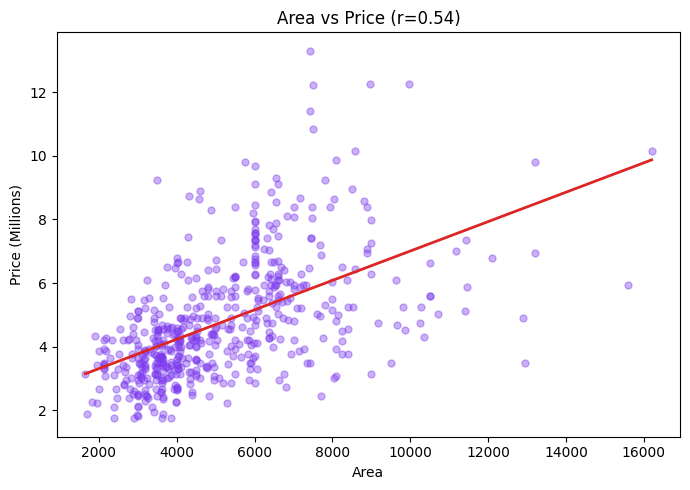

In [24]:
# Correlation: Area vs Price

r, p_corr = stats.pearsonr(Housing_cleaned['area'], Housing_cleaned['price'])

corr_area_results = pd.DataFrame({
    'Metric': ['Pearson correlation (r)', 'P-value'],
    'Value': [f'{r:.3f}', f'{p_corr:.6f}']
})

display(corr_area_results)

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(Housing_cleaned['area'], Housing_cleaned['price']/1e6, alpha=0.4, color=PURPLE, s=25)
m, b = np.polyfit(Housing_cleaned['area'], Housing_cleaned['price']/1e6, 1)
xr = np.linspace(Housing_cleaned['area'].min(), Housing_cleaned['area'].max(), 200)
ax.plot(xr, m*xr+b, color=RED, linewidth=2)
ax.set_title(f'Area vs Price (r={r:.2f})')
ax.set_xlabel('Area'); ax.set_ylabel('Price (Millions)')
plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Housing_Project\Housing_Cleaned_Correlation_vs_Causation.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

### Correlation vs Causation Critical Discussion

* **Area and Price are moderately positively correlated (r = 0.54, p < 0.001).** This relationship has a plausible causal interpretation, as larger properties typically require more land, materials, and construction costs, which can directly increase market value.

* **Air Conditioning (AC) and Price are also positively correlated.** However, this relationship is unlikely to be directly causal. AC is better interpreted as a proxy for broader property characteristics such as overall build quality, modernity, and luxury level. These underlying factors likely drive both the presence of AC and higher property prices, indicating confounding rather than direct causation.

* **Preferred Area and Price are correlated as well,** but the direction of causality is not straightforward. “Preferred area” is often defined based on existing property values, amenities, and demand, meaning the relationship may involve reverse causation or simultaneity. As such, higher prices may both influence and be influenced by location designation.

* **Framework for interpretation:** To assess causality, three questions were considered: (1) Is there a plausible mechanism linking the variables? (Area → Price: yes). (2) Could a third variable explain the relationship? (AC → Price: likely confounded by property quality). (3) Is reverse causation plausible? (Preferred Area → Price: possible).

* **Conclusion:** Among the examined relationships, **Area and Price** provides the strongest basis for a causal interpretation. In contrast, **AC** and **Preferred Area** should be interpreted as associated factors rather than confirmed causal drivers without further multivariate analysis controlling for confounding variables.


---
## Summary of Findings

| Concept | Finding |
|---------|---------|
| Descriptive Stats | Price & Area are right-skewed (mean > median); Price has the highest variance |
| Probability Distribution | Price is NOT normally distributed (Shapiro-Wilk p<0.05) |
| Hypothesis Test 1 | AC has a statistically significant effect on price (p<0.001) |
| Hypothesis Test 2 | Preferred Area has a statistically significant effect on price (p<0.001) |
| Correlation vs Causation | Area→Price is plausibly causal; AC and PrefArea are correlated but likely confounded |